In [1]:
!pip install huggingface_hub pandas numpy matplotlib seaborn scikit-learn

In [17]:
import pandas as pd
import numpy as np
from huggingface_hub import hf_hub_download, list_repo_files
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

REPO_ID = "nguyenvy/cleaned_nhanes_1988_2018"
TARGET_FILENAME = "nhanes_1988_2018_cleaned.csv"

def download_dataset(repo_id, filename):

    local_path = hf_hub_download(repo_type="dataset", repo_id=repo_id, filename=filename)
    return local_path

def list_files(repo_id):

    files = list_repo_files(repo_id=repo_id, repo_type="dataset")
    return files

In [18]:
def extract_exposome_features(df):

    demographic_prefixes = ["SEQN", "RIAGENDR", "RIDAGEYR", "RIDRETH", "DMDEDUC", "INDHHIN", "DIQ010"]

    selected_cols = [
        col for col in df.columns
        if any(col.startswith(pre) for pre in demographic_prefixes) or col.startswith("LBX")
    ]

    return df[selected_cols]

def clean_data(df):

    return df.fillna(df.median(numeric_only = True))

def optimise_memory_usage(df):

    converted_df = df.copy()
    int_cols = converted_df.select_dtypes(include = ["int"]).columns
    converted_df[int_cols] = converted_df[int_cols].apply(pd.to_numeric, downcast = "integer")
    float_cols = converted_df.select_dtypes(include = ["float"]).columns
    converted_df[float_cols] = converted_df[float_cols].apply(pd.to_numeric, downcast = "float")
    return converted_df

def process_full_dataset(file_path, chunk_size = 50000):

    processed_list = []
    for chunk in pd.read_csv(file_path, chunksize = chunk_size):
        filtered_chunk = extract_exposome_features(chunk)
        cleaned_chunk = clean_data(filtered_chunk)
        optimised_chunk = optimise_memory_usage(cleaned_chunk)
        processed_list.append(optimised_chunk)
    return pd.concat(processed_list, ignore_index = True)

In [19]:
def refine_target_variable(df, target_col = "DIQ010"):

    if target_col not in df.columns:
        return df
    df_refined = df[df[target_col].isin([1, 2])].copy()
    df_refined[target_col] = df_refined[target_col].map({1: 1, 2: 0})
    return df_refined

def visualise_feature_importance(df, target_col = "DIQ010", top_n = 15):

    X = df.drop(columns = [target_col])
    y = df[target_col]
    model = RandomForestClassifier(n_estimators = 100, random_state = 42)
    model.fit(X, y)

    importances = pd.Series(model.feature_importances_, index = X.columns)
    top_features = importances.sort_values(ascending = False).head(top_n)

    plt.figure(figsize = (10, 6))
    sns.barplot(x = top_features.values, y = top_features.index, palette = "viridis")
    plt.title(f"Top {top_n} Exposome Features for Predicting Diabetes")
    plt.xlabel("Relative Importance Score")
    plt.ylabel("Biomarker / Demographic Variable")
    plt.show()
    return top_features.index.tolist()

def train_and_evaluate_model(df, target_col = "DIQ010"):

    X = df.drop(columns = [target_col])
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size = 0.2, random_state = 42, stratify = y
    )
    clf = RandomForestClassifier(n_estimators = 100, random_state = 42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print("Accuracy Score:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    return clf

Found biological marker: LBXGH (HbA1c). Creating clinical labels...
Training model on 12508 patients using 594 exposome features...


/tmp/ipykernel_15723/843593058.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = top_features.values, y = top_features.index, palette = "viridis")


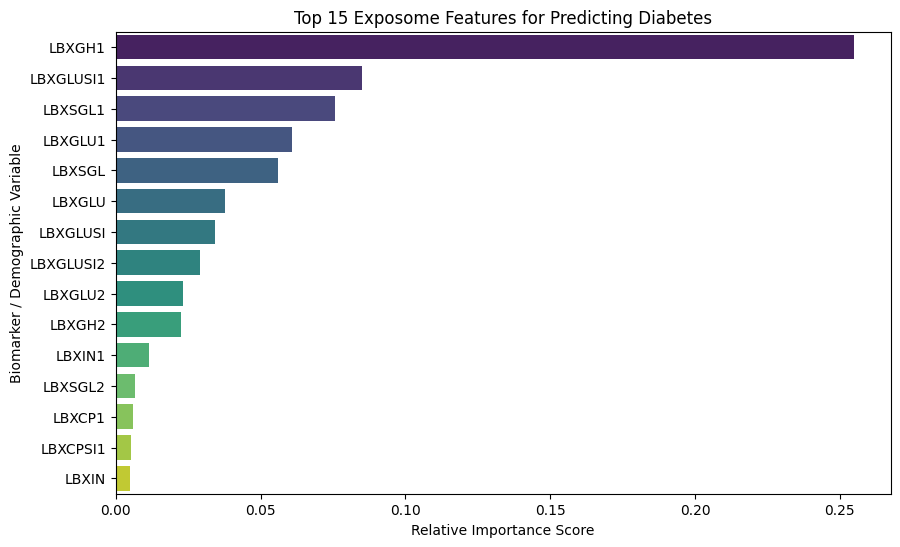


--- Clinical Prediction Results ---
Accuracy Score: 0.996802557953637

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2312
           1       0.97      0.98      0.98       190

    accuracy                           1.00      2502
   macro avg       0.99      0.99      0.99      2502
weighted avg       1.00      1.00      1.00      2502



In [20]:
# 1. DEFINE THE BIOLOGICAL TARGET
# A Glycohemoglobin (HbA1c) level >= 6.5 is the diagnostic criteria for Diabetes.
target_name = 'Clinical_Diabetes'

if 'LBXGH' in model_df.columns:
    print("Found biological marker: LBXGH (HbA1c). Creating clinical labels...")

    # Create the target: 1 if HbA1c >= 6.5, else 0
    model_df[target_name] = np.where(model_df['LBXGH'] >= 6.5, 1, 0)

    # 2. SELECT RELEVANT FEATURES
    # We want to use Age, BMI, Glucose, and the Chemicals (Exposome)
    # We look for columns starting with LBX (Chemicals) or BMX (Body Measures)
    exposome_features = [col for col in model_df.columns if col.startswith('LBX') or col.startswith('BMX')]
    core_features = ['RIDAGEYR'] # Age

    all_features = core_features + exposome_features
    # Remove the target itself and the ID from the features list
    all_features = [f for f in all_features if f not in [target_name, 'LBXGH', 'SEQN']]

    # 3. PREPARE THE DATA
    # Filter for the columns we want and drop rows that are completely empty
    X = model_df[all_features].copy()
    y = model_df[target_name]

    X = X.apply(pd.to_numeric, errors='coerce')
    X_cleaned = X.fillna(X.median())

    # 4. RUN THE MODEL
    print(f"Training model on {X_cleaned.shape[0]} patients using {len(all_features)} exposome features...")

    viz_df = pd.concat([X_cleaned, y], axis=1)

    top_features = visualise_feature_importance(viz_df, target_col=target_name)

    # 5. EVALUATE
    print("\n--- Clinical Prediction Results ---")
    train_and_evaluate_model(viz_df, target_col=target_name)

else:
    print("Could not find LBXGH. Please run print(model_df.columns.tolist()) to verify.")

Predicting Diabetes using 520 Exposome features...

--- New Feature Importance  ---


/tmp/ipykernel_15723/843593058.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = top_features.values, y = top_features.index, palette = "viridis")


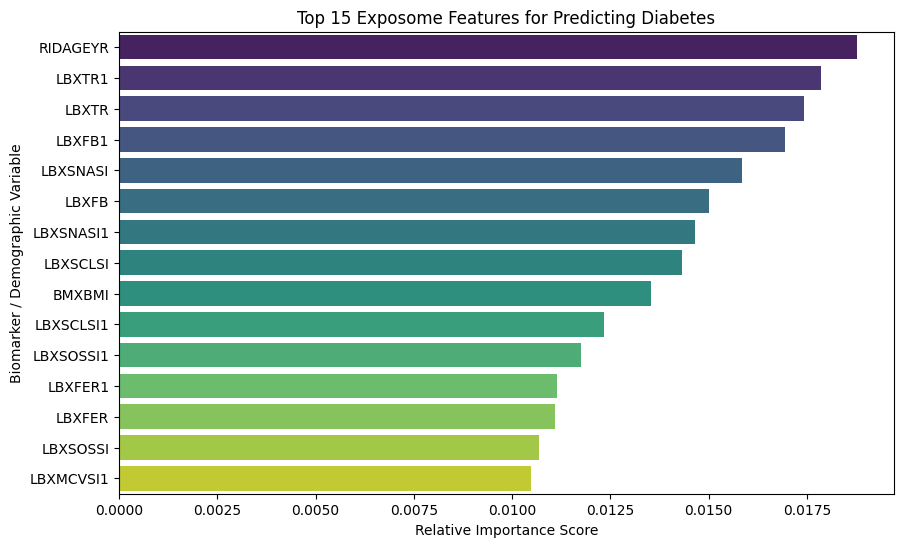


--- New Model Performance Metrics ---
Accuracy Score: 0.9256594724220624

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96      2312
           1       0.75      0.03      0.06       190

    accuracy                           0.93      2502
   macro avg       0.84      0.52      0.51      2502
weighted avg       0.91      0.93      0.89      2502



RandomForestClassifier(random_state=42)

In [21]:
# 1. DEFINE THE MARKERS TO EXCLUDE
# These are the clinical diagnostic markers we want to hide from the model
obvious_markers = ['GH', 'GLU', 'SGL', 'IN', 'CP']

# 2. IDENTIFY TARGET AND FEATURES
target_name = 'Clinical_Diabetes'
model_ready_df = model_df.copy()

# Ensure target exists
if 'LBXGH' in model_ready_df.columns:
    model_ready_df[target_name] = np.where(model_ready_df['LBXGH'] >= 6.5, 1, 0)

# Filter columns: Keep Age, BMI, and Chemicals (LBX), but EXCLUDE obvious markers
all_cols = model_ready_df.columns.tolist()
filtered_features = []

for col in all_cols:
    if col in ['RIDAGEYR', 'BMXBMI']:
        filtered_features.append(col)
    elif col.startswith('LBX'):
        is_obvious = any(marker in col for marker in obvious_markers)
        if not is_obvious:
            filtered_features.append(col)

# 3. PREPARE X (Questions) AND y (Answers)
X_hidden = model_ready_df[filtered_features].copy()
y_hidden = model_ready_df[target_name]

X_hidden = X_hidden.apply(pd.to_numeric, errors='coerce')
X_hidden_cleaned = X_hidden.fillna(X_hidden.median())

print(f"Predicting Diabetes using {len(filtered_features)} Exposome features...")

# 4. TRAIN AND VISUALISE
viz_df_hidden = pd.concat([X_hidden_cleaned, y_hidden], axis=1)

# Plot the new top features
# This will show her what predicts diabetes WITHOUT looking at blood sugar
print("\n--- New Feature Importance  ---")
visualise_feature_importance(viz_df_hidden, target_col=target_name)

# 5. EVALUATE PERFORMANCE
print("\n--- New Model Performance Metrics ---")
train_and_evaluate_model(viz_df_hidden, target_col=target_name)

Final Features Analysed: 201
Random Forest Accuracy: 93.84%
Gradient Boosting Accuracy: 85.67%
Cross-Validation Stability: 81.36% (+/- 13.60%)


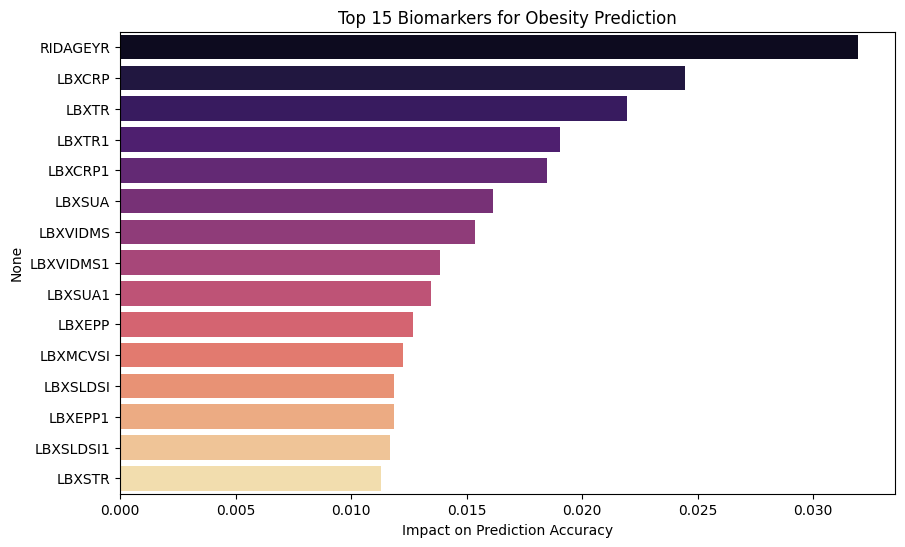

In [22]:
# --- NOW LOOKING AT EXPOSOMES WITHIN OBESITY ---


def prepare_final_data(df):

    temp_df = df.copy()

    # 1. Define Clinical Target (Obesity: BMI >= 30)
    if 'BMXBMI' in temp_df.columns:
        temp_df['Target'] = (temp_df['BMXBMI'] >= 30).astype(int)
    else:
        raise ValueError("Critical Column 'BMXBMI' missing from dataset.")

    # 2. Feature Selection (Exposome + Demographics)
    # We exclude BMI so the model must rely on blood chemistry and age
    features = [c for c in temp_df.columns if (c.startswith('LBX') or c == 'RIDAGEYR') and c != 'BMXBMI']

    X = temp_df[features].apply(pd.to_numeric, errors='coerce')
    y = temp_df['Target']

    # 3. Data Auditing: Remove columns that are entirely empty
    X = X.dropna(axis=1, how='all')

    # 4. Handle Class Imbalance via Upsampling
    # This ensures the model learns the 'Obese' profile as effectively as the 'Healthy' one
    combined = pd.concat([X, y], axis=1)
    df_0 = combined[combined.Target == 0]
    df_1 = combined[combined.Target == 1]

    df_1_upsampled = resample(df_1, replace=True, n_samples=len(df_0), random_state=42)
    balanced_df = pd.concat([df_0, df_1_upsampled])

    X_final = balanced_df.drop('Target', axis=1)
    y_final = balanced_df['Target']

    # Fill remaining NaNs with median for Random Forest compatibility
    X_final = X_final.fillna(X_final.median())

    return X_final, y_final

# --- EXECUTION & VALIDATION ---

# Prepare Data
X, y = prepare_final_data(viz_df_hidden)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model 1: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf_model.predict(X_test))

# Model 2: Hist-Gradient Boosting
hgb_model = HistGradientBoostingClassifier(random_state=42)
hgb_model.fit(X_train, y_train)
hgb_acc = accuracy_score(y_test, hgb_model.predict(X_test))

# 5-Fold Cross-Validation
cv_scores = cross_val_score(hgb_model, X, y, cv=5)

# --- REPORTING ---
print(f"Final Features Analysed: {X.shape[1]}")
print(f"Random Forest Accuracy: {rf_acc:.2%}")
print(f"Gradient Boosting Accuracy: {hgb_acc:.2%}")
print(f"Cross-Validation Stability: {cv_scores.mean():.2%} (+/- {cv_scores.std()*2:.2%})")

# Visualising the Biological Drivers
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='magma', hue=importances.index, legend=False)
plt.title('Top 15 Biomarkers for Obesity Prediction')
plt.xlabel('Impact on Prediction Accuracy')
plt.show()